# 01: Graphs, DAGs, CPDAGs, PAGs, and Evaluation

We build the graph vocabulary that the rest of the `causal-learn` tutorial will rely on. Before running PC, FCI, GES, LiNGAM, or time-series discovery, we need to understand what those algorithms return. A causal discovery result is more than a picture. It is a compact statement about adjacencies, edge directions, ambiguous directions, possible hidden confounding, and what the observed data can or cannot distinguish.

The central question here is: **when an algorithm returns a graph, how should we read it, compare it to a known answer, and report it responsibly?** We will use small example graphs so every edge can be inspected by hand. The same ideas scale to larger graphs where manual inspection is impossible.

By the end, you should be comfortable with four recurring ideas:

- A **DAG** is a fully directed acyclic graph: it says which variables are direct causes of which other variables under the assumed variable set.
- A **CPDAG** represents a Markov equivalence class of DAGs: some directions are compelled, while other edges remain reversible from observational data alone.
- A **PAG** is used when latent confounders or selection effects may exist: circles and bidirected edges communicate uncertainty and hidden-variable risk.
- Evaluation metrics such as adjacency precision, adjacency recall, arrow precision, arrow recall, and SHD answer different questions; no single score fully summarizes graph quality.


## Dataset and Experiment Setup

<!-- dataset-experiment-note -->

We use synthetic graph-discovery datasets with known structural equations and known graph truth to study **Graphs, DAGs, CPDAGs, PAGs, And Evaluation**. Known graph truth lets us see when an algorithm recovers edges, misses edges, or invents edges under violated assumptions.

Read each row as a draw from a structural causal system. Columns are observed variables, and in some lessons omitted latent variables, environments, time ordering, or non-Gaussian mechanisms are deliberately introduced. The experiment treats graph structure as the object of study. The data are useful because the graph is known before any estimator or discovery algorithm is run.

The goal is to learn what each discovery method assumes and how its output should be audited.


## Mathematical Foundation

<!-- math-foundation-note -->

A graph implies conditional independences such as

$$
X_i \perp\!\!\!\perp X_j \mid S.
$$

A CPDAG represents a Markov equivalence class, so several DAGs can share the same skeleton and v-structures. Graph recovery is often summarized by

$$
\text{precision}=\frac{\text{true positive edges}}{\text{discovered edges}}, \qquad
\text{recall}=\frac{\text{true positive edges}}{\text{true edges}}.
$$

This separation matters for learning. Adjacency recovery, direction recovery, and uncertainty about an equivalence class are different claims.



We will move from concepts to code in small steps:

1. Set up imports, output folders, and package-version checks.
2. Build a tiny true DAG using causal-learn graph objects.
3. Render the same graph in a clean teaching style.
4. Convert a simple DAG to a CPDAG and inspect why directions can disappear.
5. Compare DAGs, CPDAG-like outputs, and PAG-like outputs using endpoint marks.
6. Build graph-recovery metrics from first principles.
7. Cross-check one example with causal-learn's built-in graph-comparison utilities.

The goal is to learn what each graph is claiming and how to translate that claim into evidence a reviewer can understand.





## Tutorial Workflow

#### Setup

This first code block prepares the execution environment. It creates output directories for figures and tables, imports the graph classes we will use from `causal-learn`, and prints package versions so the lesson is reproducible. The figure-rendering code uses Graphviz through `pydot` because graph layout matters in a tutorial: if the graph is hard to read, the concept becomes harder than it needs to be.


In [1]:
# Define reusable helpers for the Setup section.
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import os
import warnings
# Keep matplotlib cache files inside the project instead of writing to a user-level cache.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pydot
from IPython.display import Image, display
from causallearn.graph.GraphNode import GraphNode
from causallearn.graph.Dag import Dag
from causallearn.graph.GeneralGraph import GeneralGraph
from causallearn.graph.Edge import Edge
from causallearn.graph.Endpoint import Endpoint
from causallearn.utils.DAG2CPDAG import dag2cpdag
from causallearn.graph.SHD import SHD
from causallearn.graph.AdjacencyConfusion import AdjacencyConfusion
from causallearn.graph.ArrowConfusion import ArrowConfusion
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 0)
pd.set_option("display.max_colwidth", 120)
NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "causal_learn":
    NOTEBOOK_DIR = Path("notebooks/tutorials/causal_learn").resolve()
else:
    NOTEBOOK_DIR = NOTEBOOK_DIR.resolve()
OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for directory in [OUTPUT_DIR, FIGURE_DIR, TABLE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)
NOTEBOOK_PREFIX = "01"
def pkg_version(package_name: str) -> str:
    """
    Return a package version string without failing the notebook if metadata is unavailable.
    
    Parameters
    ----------
    package_name : str
        Package name to look up in Python package metadata.
    
    Returns
    -------
    str
        Installed package version, or `not installed` when the package cannot be found.
    """
    try:
        return version(package_name)
    except PackageNotFoundError:
        return "not installed"
version_table = pd.DataFrame(
    [
        {"package": "causal-learn", "version": pkg_version("causal-learn")},
        {"package": "pandas", "version": pkg_version("pandas")},
        {"package": "numpy", "version": pkg_version("numpy")},
        {"package": "matplotlib", "version": pkg_version("matplotlib")},
        {"package": "seaborn", "version": pkg_version("seaborn")},
        {"package": "pydot", "version": pkg_version("pydot")},
    ]
)
version_table


,package,version
0,causal-learn,0.1.4.5
1,pandas,3.0.2
2,numpy,2.4.4
3,matplotlib,3.10.9
4,seaborn,0.13.2
5,pydot,4.0.1


The version table is a small but useful reproducibility check. Discovery algorithms are sensitive to implementation details, and graph classes can change across library versions. Keeping the versions visible makes it easier to explain later why a result may differ from another machine or tutorial.


### Graph Concept Map

This table gives the minimum vocabulary needed before touching algorithms. A common mistake is to treat every returned graph as if it were a fully oriented causal DAG. That is too strong for many discovery methods. PC often returns a CPDAG-like object because observational data cannot always orient every edge. FCI returns a PAG-like object because it explicitly allows hidden confounding. Score-based methods such as GES also work over equivalence classes and avoid simply selecting one arbitrary DAG.

Read this table as a translation layer between algorithm output and plain English.


| concept | stands_for | edge_example | plain_language | why_it_matters |
| --- | --- | --- | --- | --- |
| DAG | Directed acyclic graph | A -> B | A is represented as a direct cause of B, and cycles are prohibited. | This is the cleanest causal story. Observational discovery often leaves some directions unresolved. |
| Skeleton | Adjacency pattern without directions | A - B | A and B are connected somehow, but the direction is ignored. | Skeleton quality asks whether the algorithm found the right variable pairs before asking whether directions are right. |
| CPDAG | Completed partially directed acyclic graph | A -> B and B - C | Directed edges are compelled across an equivalence class; undirected edges are reversible. | It prevents overclaiming directions that the observed conditional independences cannot identify. |
| PAG | Partial ancestral graph | A o-> B or A <-> B | Endpoint marks encode uncertainty and possible hidden confounding. | It is the right language when unmeasured common causes may be present. |
| SHD | Structural Hamming Distance | count of edits | How many edge additions, deletions, or orientation changes are needed to move from one graph to another. | It is compact, but it hides which kind of error occurred unless paired with precision/recall metrics. |


This table sets up the main reporting habit for causal discovery: separate **whether two variables are connected** from **whether the direction is known**. A graph can have an excellent skeleton and still be weak on directions. That can be the correct output when the data genuinely do not contain enough information to orient an edge.


### A Small Teaching DAG

Now we create a small true graph. The variables are generic and product-analytics flavored, while the graph is artificial so we can know the answer. We will use it as a controlled reference for the rest of the lesson.

The story is:

- `Need` and `Intent` jointly influence whether a user sees a good `Match`.
- `Match` drives `Engagement`.
- `Engagement` affects both `Renewal` and `Support` demand.
- `Need` also directly affects `Renewal`, so not all renewal differences are explained by engagement.

This is a DAG because every edge has one direction and there is no directed cycle.


In [2]:
node_labels = {
    "Need": "User\nneed",
    "Intent": "Current\nintent",
    "Match": "Recommendation\nmatch",
    "Engagement": "Engagement\ndepth",
    "Renewal": "Future\nrenewal",
    "Support": "Support\ncontacts",
}
true_edge_table = pd.DataFrame(
    [
        {"source": "Need", "target": "Match", "mark": "-->", "reason": "Need affects what match quality means for the user."},
        {"source": "Intent", "target": "Match", "mark": "-->", "reason": "Current intent affects which recommendation feels relevant."},
        {"source": "Match", "target": "Engagement", "mark": "-->", "reason": "Better matching increases downstream engagement."},
        {"source": "Engagement", "target": "Renewal", "mark": "-->", "reason": "Deeper engagement can raise future value."},
        {"source": "Engagement", "target": "Support", "mark": "-->", "reason": "More engagement can create more opportunities for support contact."},
        {"source": "Need", "target": "Renewal", "mark": "-->", "reason": "Underlying need can directly affect renewal even after engagement."},
    ]
)
true_edge_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_true_dag_edges.csv", index=False)
true_edge_table


,source,target,mark,reason
0,Need,Match,-->,Need affects what match quality means for the user.
1,Intent,Match,-->,Current intent affects which recommendation feels relevant.
2,Match,Engagement,-->,Better matching increases downstream engagement.
3,Engagement,Renewal,-->,Deeper engagement can raise future value.
4,Engagement,Support,-->,More engagement can create more opportunities for support contact.
5,Need,Renewal,-->,Underlying need can directly affect renewal even after engagement.


The edge table is deliberately explicit. In larger projects, keeping an edge table next to the graph helps reviewers understand whether an arrow came from domain assumptions, from an algorithm, or from a simulation design. Here it is our ground-truth answer key.


#### Building the DAG with causal-learn Objects

The previous step was a plain pandas table. The code below builds the same graph using causal-learn's graph classes. The important pieces are:

- `GraphNode`: wraps the variable name.
- `Dag`: stores a directed acyclic graph.
- `Edge`: stores two endpoint marks.
- `Endpoint.TAIL` and `Endpoint.ARROW`: together represent a directed edge from source to target.

In causal-learn notation, `A --> B` means the endpoint at `A` is a tail and the endpoint at `B` is an arrowhead.


In [3]:
# Define reusable helpers for the Building The DAG With causal-learn Objects section.
def build_causallearn_graph(node_names, edge_table, graph_class=GeneralGraph):
    """
    Build a causal-learn graph from a table with source, target, and mark columns.
    
    Parameters
    ----------
    node_names : list[str]
        Variable names used to create graph nodes.
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    graph_class : type
        causal-learn graph class used to construct the graph object.
    
    Returns
    -------
    tuple
        Tuple containing graph, node_map.
    """
    nodes = [GraphNode(name) for name in node_names]
    node_map = {node.get_name(): node for node in nodes}
    graph = graph_class(nodes)
    endpoint_map = {
        "-->": (Endpoint.TAIL, Endpoint.ARROW),
        "<--": (Endpoint.ARROW, Endpoint.TAIL),
        "---": (Endpoint.TAIL, Endpoint.TAIL),
        "<->": (Endpoint.ARROW, Endpoint.ARROW),
        "o->": (Endpoint.CIRCLE, Endpoint.ARROW),
        "<-o": (Endpoint.ARROW, Endpoint.CIRCLE),
        "o-o": (Endpoint.CIRCLE, Endpoint.CIRCLE),
    }
    for row in edge_table.itertuples(index=False):
        end1, end2 = endpoint_map[row.mark]
        graph.add_edge(Edge(node_map[row.source], node_map[row.target], end1, end2))
    return graph, node_map
node_order = list(node_labels)
true_dag, true_node_map = build_causallearn_graph(node_order, true_edge_table, graph_class=Dag)
causal_learn_edges = pd.DataFrame(
    {
        "causal_learn_edge_string": [str(edge) for edge in true_dag.get_graph_edges()]
    }
)
causal_learn_edges


,causal_learn_edge_string
0,Need --> Match
1,Need --> Renewal
2,Intent --> Match
3,Match --> Engagement
4,Engagement --> Renewal
5,Engagement --> Support


The causal-learn edge strings match the edge table: every edge is directed. This is the object form that algorithms and built-in graph metrics expect. The table form is still useful because it is easier to read, save, modify, and render in a teaching lesson.


### Rendering the Teaching DAG

The next helper renders edge tables with Graphviz. The visual conventions are the same ones we will use throughout the tutorial:

- `-->` is a directed edge.
- `---` is an undirected or reversible CPDAG edge.
- `<->` is a bidirected edge, often used to flag latent common-cause risk in mixed graphs.
- `o->`, `<-o`, and `o-o` are PAG-style uncertain endpoints.

The fixed node positions are not part of the causal model. They simply make the picture easier to read and keep the analysis output stable across runs.


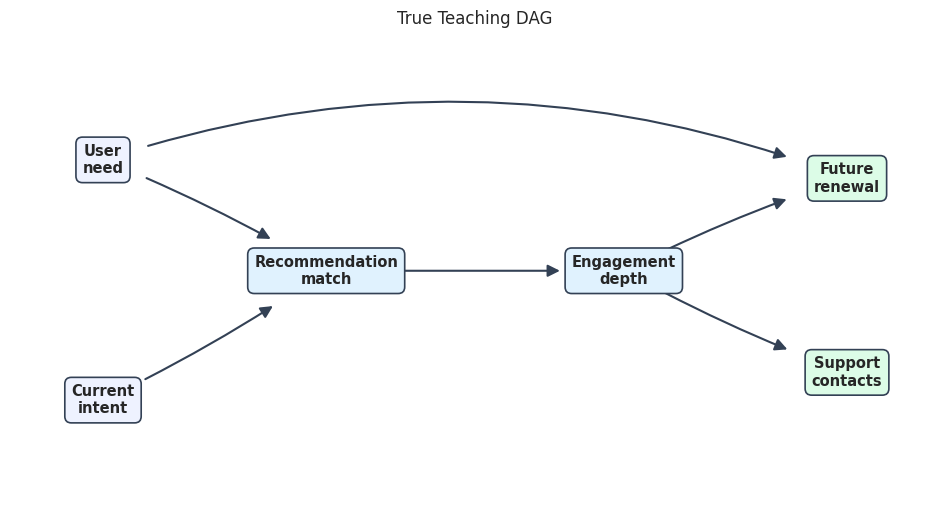

PosixPath('notebooks/tutorials/causal_learn/outputs/figures/01_true_teaching_dag.png')

In [4]:
# Define reusable helpers for the Rendering The Teaching DAG section.
def render_edge_table_graph(
    edge_table,
    labels,
    positions,
    title,
    output_path,
    node_colors=None,
    edge_radii=None,
    circle_positions=None,
    edge_color="#334155",
    figsize=(12, 6),
):
    """
    Render an edge table using the shared tutorial DAG style.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    labels : dict[str, str]
        Display labels used for graph nodes in the rendered figure.
    positions : dict
        Node positions used to draw the graph.
    title : str
        Title shown above the plot.
    output_path : str or pathlib.Path
        Output path where the rendered figure is saved.
    node_colors : dict[str, str] or None
        Optional mapping from node names to display colors.
    edge_radii : dict or None
        Optional curvature settings for individual plotted edges.
    circle_positions : dict or None
        Optional coordinates for PAG circle endpoint marks.
    edge_color : str
        Color used for rendered edges or arrows.
    figsize : tuple[float, float]
        Matplotlib figure size for the rendered graph.
    
    Returns
    -------
    pathlib.Path
        Path to the saved graph figure rendered from the edge table.
    """
    node_colors = node_colors or {node: "#e0f2fe" for node in labels}
    edge_radii = edge_radii or {}
    circle_positions = circle_positions or {}
    fig, ax = plt.subplots(figsize=figsize)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_axis_off()
    endpoint_circle_queue = []
    def endpoint_circle(source, target, near_source=True):
        """
        Queue a PAG circle endpoint, using explicit positions when provided.
        
        Parameters
        ----------
        source : str
            Source node name for a graph edge.
        target : str or array-like
            Outcome, metric, or variable whose residualized or transformed value is needed.
        near_source : bool
            Whether the endpoint mark should be placed near the source node.
        
        Returns
        -------
        None
            Performs the endpoint circle side effect and returns no value.
        """
        side = "source" if near_source else "target"
        key = (source, target, side)
        if key in circle_positions:
            point = np.array(circle_positions[key], dtype=float)
        else:
            source_xy = np.array(positions[source], dtype=float)
            target_xy = np.array(positions[target], dtype=float)
            t = 0.18 if near_source else 0.82
            point = source_xy + t * (target_xy - source_xy)
        endpoint_circle_queue.append(point)
    for row in edge_table.itertuples(index=False):
        source = row.source
        target = row.target
        mark = row.mark
        rad = edge_radii.get((source, target), edge_radii.get((target, source), 0.0))
        linestyle = "-"
        arrowstyle = "-|>"
        xy = positions[target]
        xytext = positions[source]
        if mark == "<--":
            xy = positions[source]
            xytext = positions[target]
        elif mark == "---":
            arrowstyle = "-"
        elif mark == "<->":
            arrowstyle = "<|-|>"
        elif mark == "o->":
            endpoint_circle(source, target, near_source=True)
        elif mark == "<-o":
            xy = positions[source]
            xytext = positions[target]
            endpoint_circle(source, target, near_source=False)
        elif mark == "o-o":
            arrowstyle = "-"
            endpoint_circle(source, target, near_source=True)
            endpoint_circle(source, target, near_source=False)
        ax.annotate(
            "",
            xy=xy,
            xytext=xytext,
            arrowprops=dict(
                arrowstyle=arrowstyle,
                color=edge_color,
                linewidth=1.5,
                mutation_scale=18,
                shrinkA=34,
                shrinkB=46,
                linestyle=linestyle,
                connectionstyle=f"arc3,rad={rad}",
            ),
            zorder=1,
        )
    for point in endpoint_circle_queue:
        ax.scatter(
            point[0],
            point[1],
            s=34,
            facecolors="white",
            edgecolors=edge_color,
            linewidths=1.5,
            zorder=3,
        )
    for node, (x, y) in positions.items():
        ax.text(
            x,
            y,
            labels[node],
            ha="center",
            va="center",
            fontsize=10.5,
            fontweight="bold",
            bbox=dict(
                boxstyle="round,pad=0.45",
                facecolor=node_colors.get(node, "#e0f2fe"),
                edgecolor="#334155",
                linewidth=1.2,
            ),
            zorder=4,
        )
    ax.set_title(title, pad=18)
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.show()
    return output_path
teaching_positions = {
    "Need": (0.10, 0.76),
    "Intent": (0.10, 0.24),
    "Match": (0.34, 0.52),
    "Engagement": (0.66, 0.52),
    "Renewal": (0.90, 0.72),
    "Support": (0.90, 0.30),
}
teaching_node_colors = {
    "Need": "#eef2ff",
    "Intent": "#eef2ff",
    "Match": "#e0f2fe",
    "Engagement": "#e0f2fe",
    "Renewal": "#dcfce7",
    "Support": "#dcfce7",
}
teaching_edge_radii = {
    ("Need", "Match"): -0.04,
    ("Intent", "Match"): 0.04,
    ("Match", "Engagement"): 0.00,
    ("Engagement", "Renewal"): -0.04,
    ("Engagement", "Support"): 0.04,
    ("Need", "Renewal"): -0.18,
    ("Intent", "Support"): 0.18,
}
true_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_true_teaching_dag.png"
render_edge_table_graph(
    true_edge_table,
    node_labels,
    teaching_positions,
    "True Teaching DAG",
    true_dag_path,
    node_colors=teaching_node_colors,
    edge_radii=teaching_edge_radii,
)


The rendered graph makes two structural features easy to see. First, `Need` and `Intent` form a collider at `Match`: `Need -> Match <- Intent`. Second, `Renewal` has two parents, `Need` and `Engagement`. These patterns matter because v-structures are often what allow observational discovery algorithms to orient some edges.


#### Endpoint Vocabulary

causal-learn graphs use endpoint marks as well as whole-edge labels. This matters because algorithms such as FCI can return edges where one endpoint is known and the other is uncertain.

The whole-edge notation is a compact way to read the two endpoint marks together.


| whole_edge_mark | endpoint_at_A | endpoint_at_B | typical_graph | meaning |
| --- | --- | --- | --- | --- |
| A --> B | TAIL | ARROW | DAG, CPDAG, PAG | A is oriented as an ancestor/cause-side endpoint of B. |
| A --- B | TAIL | TAIL | CPDAG | A and B are adjacent, but this edge is reversible within the equivalence class. |
| A o-> B | CIRCLE | ARROW | PAG | The endpoint near A is uncertain; B has an arrowhead on this edge. |
| A <-> B | ARROW | ARROW | PAG or mixed graph | Often read as possible latent common-cause structure between A and B. |
| A o-o B | CIRCLE | CIRCLE | PAG | The relationship is adjacent, but both endpoint orientations remain unresolved. |


This endpoint view is the cleanest way to avoid overclaiming. A circle marks an unresolved endpoint. When writing up a discovery result, those unresolved marks should be preserved so the report shows the remaining orientation uncertainty.


#### DAG to CPDAG: Why Some Directions Disappear

A CPDAG represents all DAGs that imply the same observational conditional independences. If several DAGs are Markov equivalent, observational data alone cannot choose among them without extra assumptions, interventions, time ordering, or background knowledge.

The classic example is a three-node chain. `A -> B -> C` and `A <- B -> C` share the same skeleton and have no unshielded collider, so they are Markov equivalent. In a CPDAG, the reversible edges become undirected.


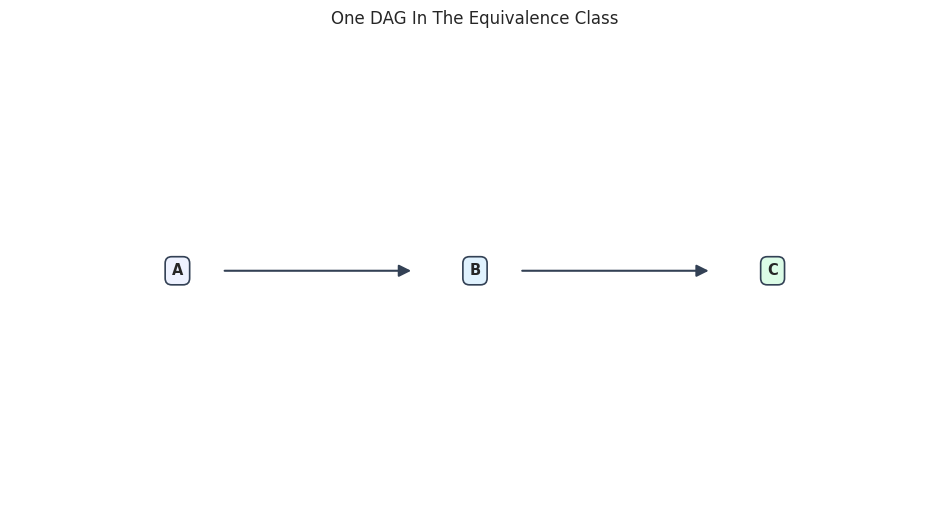

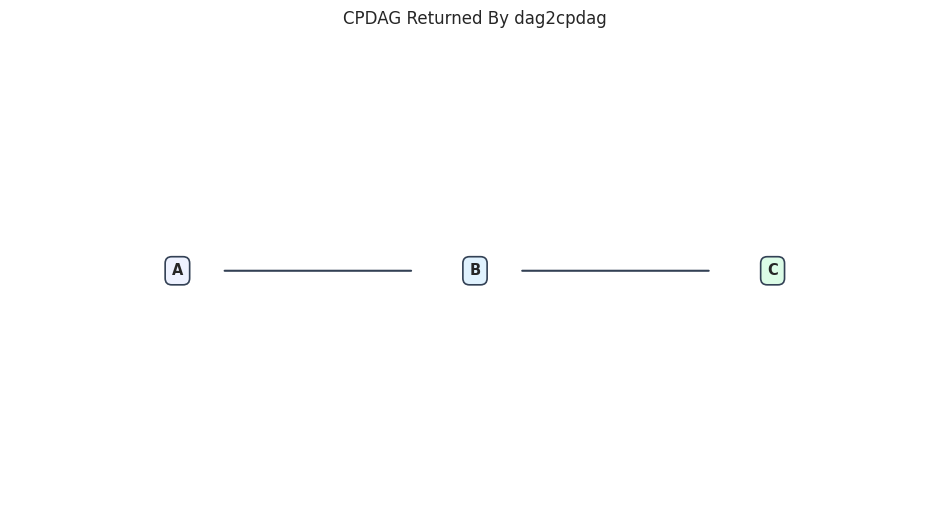

,source,target,endpoint_at_source,endpoint_at_target,mark,causal_learn_string
0,A,B,TAIL,TAIL,---,A --- B
1,B,C,TAIL,TAIL,---,B --- C


In [5]:
# Define reusable helpers for the DAG To CPDAG: Why Some Directions Disappear section.
chain_labels = {"A": "A", "B": "B", "C": "C"}
chain_positions = {"A": (0.18, 0.52), "B": (0.50, 0.52), "C": (0.82, 0.52)}
chain_node_colors = {"A": "#eef2ff", "B": "#e0f2fe", "C": "#dcfce7"}
chain_edges = pd.DataFrame(
    [
        {"source": "A", "target": "B", "mark": "-->", "reason": "First link in a simple chain."},
        {"source": "B", "target": "C", "mark": "-->", "reason": "Second link in a simple chain."},
    ]
)
chain_dag, _ = build_causallearn_graph(list(chain_labels), chain_edges, graph_class=Dag)
chain_cpdag = dag2cpdag(chain_dag)
def causallearn_edges_to_table(graph):
    """
    Convert causal-learn edges into a small readable endpoint table.
    
    Parameters
    ----------
    graph : object
        Graph object returned by causal-learn or constructed from the edge table.
    
    Returns
    -------
    pd.DataFrame
        Graph edge table for causallearn edges to table, including node names and edge-orientation information where available.
    """
    records = []
    for edge in graph.get_graph_edges():
        endpoint1 = str(edge.get_endpoint1())
        endpoint2 = str(edge.get_endpoint2())
        source = edge.get_node1().get_name()
        target = edge.get_node2().get_name()
        mark_lookup = {
            ("TAIL", "ARROW"): "-->",
            ("ARROW", "TAIL"): "<--",
            ("TAIL", "TAIL"): "---",
            ("ARROW", "ARROW"): "<->",
            ("CIRCLE", "ARROW"): "o->",
            ("ARROW", "CIRCLE"): "<-o",
            ("CIRCLE", "CIRCLE"): "o-o",
        }
        records.append(
            {
                "source": source,
                "target": target,
                "endpoint_at_source": endpoint1,
                "endpoint_at_target": endpoint2,
                "mark": mark_lookup.get((endpoint1, endpoint2), f"{endpoint1}/{endpoint2}"),
                "causal_learn_string": str(edge),
            }
        )
    return pd.DataFrame(records)
chain_cpdag_table = causallearn_edges_to_table(chain_cpdag)
chain_cpdag_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_chain_cpdag_edges.csv", index=False)
chain_dag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_chain_dag.png"
chain_cpdag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_chain_cpdag.png"
render_edge_table_graph(chain_edges, chain_labels, chain_positions, "One DAG In The Equivalence Class", chain_dag_path, node_colors=chain_node_colors)
render_edge_table_graph(
    chain_cpdag_table.assign(reason="reversible edge in the CPDAG"),
    chain_labels,
    chain_positions,
    "CPDAG Returned By dag2cpdag",
    chain_cpdag_path,
    node_colors=chain_node_colors,
    edge_color="#334155",
)
chain_cpdag_table


The CPDAG table shows undirected `---` edges. That does not mean there is no causal relationship. It means the equivalence class does not force a single direction for those adjacencies. This is one of the most important habits in causal discovery reporting: uncertainty about direction should stay visible.


#### Markov Equivalence and V-Structures

Two DAGs are Markov equivalent when they have the same skeleton and the same unshielded colliders, also called v-structures. The next step compares three small graphs:

- A chain: `A -> B -> C`.
- A fork: `A <- B -> C`.
- A collider: `A -> B <- C`.

The chain and fork have the same skeleton and no collider. The collider has the same skeleton but a different v-structure, so it implies different conditional independence behavior.


In [6]:
# Define reusable helpers for the Markov Equivalence And V-Structures section.
def skeleton_from_edges(edge_pairs):
    """
    Return undirected adjacencies as sorted frozensets.
    
    Parameters
    ----------
    edge_pairs : collection[tuple[str, str]]
        Directed source-target pairs used to derive skeletons or v-structures.
    
    Returns
    -------
    set[frozenset[str]]
        Undirected skeleton edge set converted from directed edge pairs.
    """
    return {frozenset([source, target]) for source, target in edge_pairs}
def v_structures_from_edges(edge_pairs):
    """
    Find unshielded colliders A -> B <- C in a directed edge list.
    
    Parameters
    ----------
    edge_pairs : collection[tuple[str, str]]
        Directed source-target pairs used to derive skeletons or v-structures.
    
    Returns
    -------
    list[tuple[str, str, str]]
        Sorted list of v-structures implied by the edge set.
    """
    parents = {}
    all_edges = set(edge_pairs)
    for source, target in edge_pairs:
        parents.setdefault(target, set()).add(source)
    v_structures = []
    for child, parent_set in parents.items():
        sorted_parents = sorted(parent_set)
        for i, left_parent in enumerate(sorted_parents):
            for right_parent in sorted_parents[i + 1 :]:
                parents_adjacent = (
                    (left_parent, right_parent) in all_edges
                    or (right_parent, left_parent) in all_edges
                )
                if not parents_adjacent:
                    v_structures.append(f"{left_parent} -> {child} <- {right_parent}")
    return sorted(v_structures)
small_graphs = {
    "chain_A_to_B_to_C": [("A", "B"), ("B", "C")],
    "fork_B_to_A_and_C": [("B", "A"), ("B", "C")],
    "collider_A_and_C_to_B": [("A", "B"), ("C", "B")],
}
equivalence_rows = []
for graph_name, edges in small_graphs.items():
    equivalence_rows.append(
        {
            "graph": graph_name,
            "directed_edges": ", ".join([f"{a}->{b}" for a, b in edges]),
            "skeleton": ", ".join(sorted(["-".join(sorted(edge)) for edge in skeleton_from_edges(edges)])),
            "unshielded_colliders": "; ".join(v_structures_from_edges(edges)) or "none",
        }
    )
equivalence_table = pd.DataFrame(equivalence_rows)
equivalence_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_markov_equivalence_examples.csv", index=False)
equivalence_table


,graph,directed_edges,skeleton,unshielded_colliders
0,chain_A_to_B_to_C,"A->B, B->C","A-B, B-C",none
1,fork_B_to_A_and_C,"B->A, B->C","A-B, B-C",none
2,collider_A_and_C_to_B,"A->B, C->B","A-B, B-C",A -> B <- C


The chain and fork rows share the same skeleton and both list `none` for unshielded colliders. The collider row has the same adjacencies but a different collider pattern. This is why v-structures are so valuable: they are one of the few orientation patterns observational conditional independence tests can often identify.


#### PAG-Style Edge Marks

A PAG is the graph language used by algorithms such as FCI when latent confounders or selection effects are allowed. In practice, this means the algorithm is less willing to pretend that every relevant cause has been measured.

The graph below is not the output of an algorithm. It is a hand-made example graph showing the edge marks you will later see in FCI-style lessons.


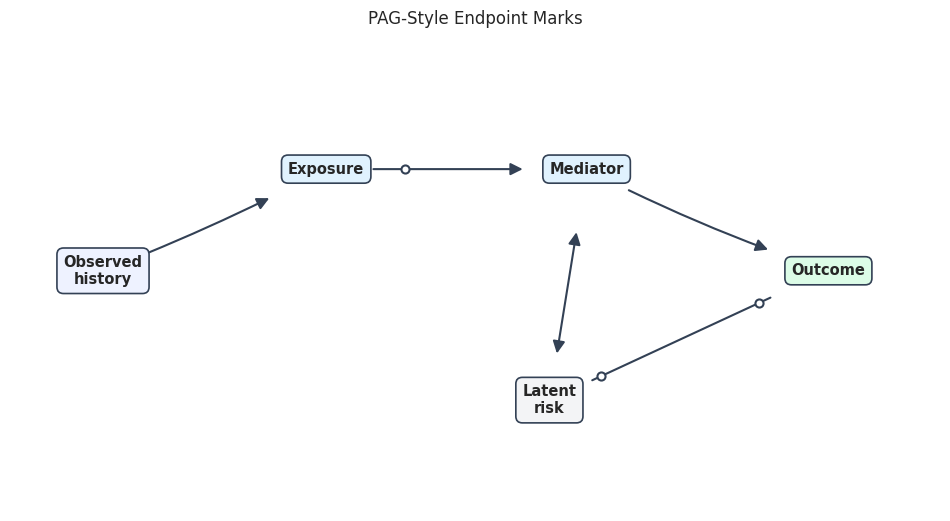

,source,target,mark,meaning,causal_learn_string
0,X,A,-->,Observed history is oriented into exposure.,X --> A
1,A,M,o->,The mediator endpoint is an arrowhead; the exposure-side endpoint is unresolved.,A o-> M
2,M,Y,-->,Mediator is oriented into outcome.,M --> Y
3,U,M,<->,Bidirected edge flags hidden common-cause style risk.,M <-> U
4,U,Y,o-o,Both endpoint orientations remain unresolved for this illustrative relationship.,Y o-o U


In [7]:
# Prepare intermediate objects for the PAG-Style Edge Marks section.
pag_labels = {
    "X": "Observed\nhistory",
    "A": "Exposure",
    "M": "Mediator",
    "Y": "Outcome",
    "U": "Latent\nrisk",
}
pag_positions = {
    "X": (0.10, 0.52),
    "A": (0.34, 0.74),
    "M": (0.62, 0.74),
    "Y": (0.88, 0.52),
    "U": (0.58, 0.24),
}
pag_node_colors = {
    "X": "#eef2ff",
    "A": "#e0f2fe",
    "M": "#e0f2fe",
    "Y": "#dcfce7",
    "U": "#f3f4f6",
}
pag_edge_radii = {
    ("X", "A"): 0.03,
    ("A", "M"): 0.00,
    ("M", "Y"): 0.04,
    ("U", "M"): 0.00,
    ("U", "Y"): 0.00,
}
pag_circle_positions = {
    ("A", "M", "source"): (0.425, 0.74),
    ("U", "Y", "source"): (0.635, 0.292),
    ("U", "Y", "target"): (0.805, 0.450),
}
pag_edge_table = pd.DataFrame(
    [
        {"source": "X", "target": "A", "mark": "-->", "meaning": "Observed history is oriented into exposure."},
        {"source": "A", "target": "M", "mark": "o->", "meaning": "The mediator endpoint is an arrowhead; the exposure-side endpoint is unresolved."},
        {"source": "M", "target": "Y", "mark": "-->", "meaning": "Mediator is oriented into outcome."},
        {"source": "U", "target": "M", "mark": "<->", "meaning": "Bidirected edge flags hidden common-cause style risk."},
        {"source": "U", "target": "Y", "mark": "o-o", "meaning": "Both endpoint orientations remain unresolved for this illustrative relationship."},
    ]
)
pag_graph, _ = build_causallearn_graph(list(pag_labels), pag_edge_table, graph_class=GeneralGraph)
pag_strings = [str(edge) for edge in pag_graph.get_graph_edges()]
pag_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pag_edge_marks.png"
render_edge_table_graph(
    pag_edge_table,
    pag_labels,
    pag_positions,
    "PAG-Style Endpoint Marks",
    pag_path,
    node_colors=pag_node_colors,
    edge_radii=pag_edge_radii,
    circle_positions=pag_circle_positions,
    edge_color="#334155",
)
pag_edge_table.assign(causal_learn_string=pag_strings)


The key habit is to read each endpoint separately. For example, `A o-> M` is weaker than `A -> M`: it says there is an arrowhead at `M`, while the endpoint near `A` remains uncertain. This is exactly the sort of nuance that disappears if a PAG is redrawn as a simple DAG.





## Diagnostics and Interpretation

### Graph Evaluation Metrics from First Principles

When a true graph is known, usually through simulation or a benchmark, we can evaluate learned graphs. It is useful to split evaluation into two layers:

- **Adjacency evaluation** asks whether the right pairs of variables were connected, ignoring direction.
- **Direction evaluation** asks whether the directed arrows match the true directions.

A conservative algorithm may recover the right adjacencies but leave many edges undirected. That should score well on skeleton recall, while arrow recall may remain lower because some directions are unresolved. This distinction is more informative than one overall score.


In [8]:
# Define reusable helpers for the Graph Evaluation Metrics From First Principles section.
def directed_edges_from_table(edge_table):
    """
    Extract directed claims from an edge table.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    
    Returns
    -------
    set[tuple[str, str]]
        Directed source-target edge set extracted from a table.
    """
    directed = set()
    for row in edge_table.itertuples(index=False):
        if row.mark == "-->":
            directed.add((row.source, row.target))
        elif row.mark == "<--":
            directed.add((row.target, row.source))
    return directed
def skeleton_from_table(edge_table):
    """
    Extract adjacency claims from an edge table, ignoring endpoint direction.
    
    Parameters
    ----------
    edge_table : pd.DataFrame
        Table of source-target edges and endpoint marks to convert, draw, or score.
    
    Returns
    -------
    set[frozenset[str]]
        Undirected skeleton edge set extracted from an edge table.
    """
    return {frozenset([row.source, row.target]) for row in edge_table.itertuples(index=False)}
def safe_ratio(numerator, denominator):
    """
    Idea: Compute a ratio while returning a missing value when the denominator is too small to support the comparison.
    
    Parameters
    ----------
    numerator : float
        Numerator of the ratio being computed.
    denominator : float
        Denominator of the ratio being computed.
    
    Returns
    -------
    float
        Ratio value, or NaN when the denominator cannot support a stable ratio.
    """
    return np.nan if denominator == 0 else numerator / denominator
def evaluate_edge_table(candidate_name, truth_table, estimated_table):
    """
    Compute readable skeleton and arrow metrics for one estimated graph.
    
    Parameters
    ----------
    candidate_name : str
        Readable name for the candidate graph being evaluated.
    truth_table : pd.DataFrame
        Oracle edge table used as the graph-recovery benchmark.
    estimated_table : pd.DataFrame
        Estimated edge table whose recovery quality is being evaluated.
    
    Returns
    -------
    dict[str, object]
        Graph-recovery metrics including skeleton precision/recall, arrow precision/recall, and edit-style error counts.
    """
    truth_skeleton = skeleton_from_table(truth_table)
    estimated_skeleton = skeleton_from_table(estimated_table)
    truth_directed = directed_edges_from_table(truth_table)
    estimated_directed = directed_edges_from_table(estimated_table)
    skeleton_tp = len(truth_skeleton & estimated_skeleton)
    skeleton_fp = len(estimated_skeleton - truth_skeleton)
    skeleton_fn = len(truth_skeleton - estimated_skeleton)
    arrow_tp = len(truth_directed & estimated_directed)
    arrow_fp = len(estimated_directed - truth_directed)
    arrow_fn = len(truth_directed - estimated_directed)
    reversed_arrows = sum((target, source) in estimated_directed for source, target in truth_directed)
    skeleton_precision = safe_ratio(skeleton_tp, skeleton_tp + skeleton_fp)
    skeleton_recall = safe_ratio(skeleton_tp, skeleton_tp + skeleton_fn)
    arrow_precision = safe_ratio(arrow_tp, arrow_tp + arrow_fp)
    arrow_recall = safe_ratio(arrow_tp, arrow_tp + arrow_fn)
    return {
        "candidate": candidate_name,
        "skeleton_tp": skeleton_tp,
        "skeleton_fp": skeleton_fp,
        "skeleton_fn": skeleton_fn,
        "skeleton_precision": skeleton_precision,
        "skeleton_recall": skeleton_recall,
        "arrow_tp": arrow_tp,
        "arrow_fp": arrow_fp,
        "arrow_fn": arrow_fn,
        "arrow_precision": arrow_precision,
        "arrow_recall": arrow_recall,
        "reversed_arrows": reversed_arrows,
        "shd_like_edit_count": skeleton_fp + skeleton_fn + reversed_arrows,
    }
perfect_estimate = true_edge_table.copy()
extra_adjacency = pd.concat(
    [
        true_edge_table,
        pd.DataFrame(
            [{"source": "Intent", "target": "Support", "mark": "-->", "reason": "Spurious extra edge."}]
        ),
    ],
    ignore_index=True,
)
missing_and_reversed = pd.DataFrame(
    [
        {"source": "Need", "target": "Match", "mark": "-->", "reason": "Correct."},
        {"source": "Intent", "target": "Match", "mark": "-->", "reason": "Correct."},
        {"source": "Engagement", "target": "Match", "mark": "-->", "reason": "Reversed version of Match -> Engagement."},
        {"source": "Engagement", "target": "Renewal", "mark": "-->", "reason": "Correct."},
        {"source": "Engagement", "target": "Support", "mark": "-->", "reason": "Correct."},
    ]
)
conservative_cpdag_like = true_edge_table.copy()
conservative_cpdag_like.loc[
    conservative_cpdag_like["source"].eq("Match") & conservative_cpdag_like["target"].eq("Engagement"),
    "mark",
] = "---"
conservative_cpdag_like.loc[
    conservative_cpdag_like["source"].eq("Engagement") & conservative_cpdag_like["target"].eq("Support"),
    "mark",
] = "---"
conservative_cpdag_like["reason"] = "Same adjacency set, with two directions left unresolved."
candidate_tables = {
    "perfect_dag": perfect_estimate,
    "extra_adjacency": extra_adjacency,
    "missing_and_reversed": missing_and_reversed,
    "conservative_cpdag_like": conservative_cpdag_like,
}
evaluation_table = pd.DataFrame(
    [evaluate_edge_table(name, true_edge_table, table) for name, table in candidate_tables.items()]
)
evaluation_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_custom_graph_evaluation_metrics.csv", index=False)
evaluation_table


,candidate,skeleton_tp,skeleton_fp,skeleton_fn,skeleton_precision,skeleton_recall,arrow_tp,arrow_fp,arrow_fn,arrow_precision,arrow_recall,reversed_arrows,shd_like_edit_count
0,perfect_dag,6,0,0,1.000000,1.000000,6,0,0,1.000000,1.000000,0,0
1,extra_adjacency,6,1,0,0.857143,1.000000,6,1,0,0.857143,1.000000,0,1
2,missing_and_reversed,5,0,1,1.000000,0.833333,4,1,2,0.800000,0.666667,1,2
3,conservative_cpdag_like,6,0,0,1.000000,1.000000,4,0,2,1.000000,0.666667,0,0


The metric table shows why multiple scores are needed. The conservative CPDAG-like candidate has perfect skeleton precision and recall because it connects the right variable pairs, but its arrow recall is lower because it refuses to orient two edges. The missing-and-reversed candidate loses both an adjacency and a direction, which is a more serious structural error.


### Visual Comparison of Candidate Graphs

Tables are precise, but visual comparison helps diagnose the type of mistake. The next step renders each candidate graph using the same node positions as the true DAG. Keeping the layout fixed makes differences easier to spot: an extra edge, a missing edge, a reversed edge, or an unresolved edge mark becomes visually obvious.


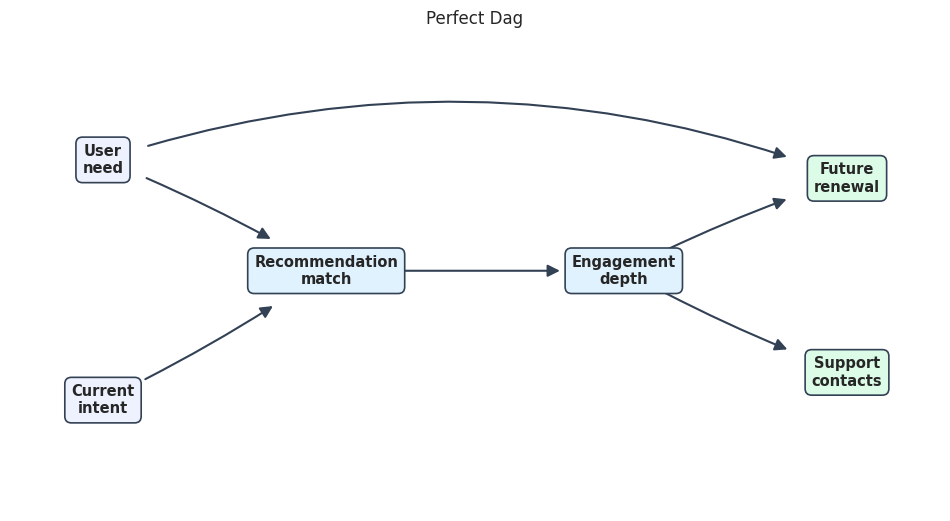

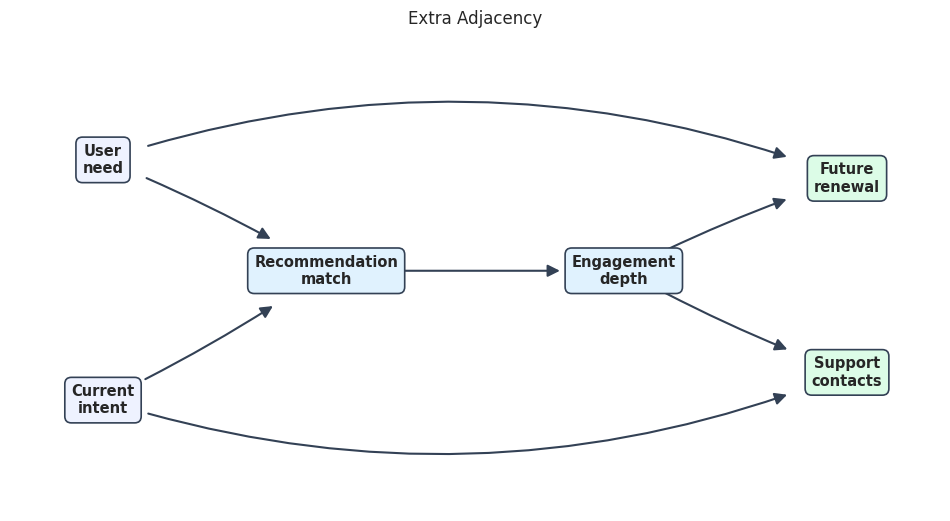

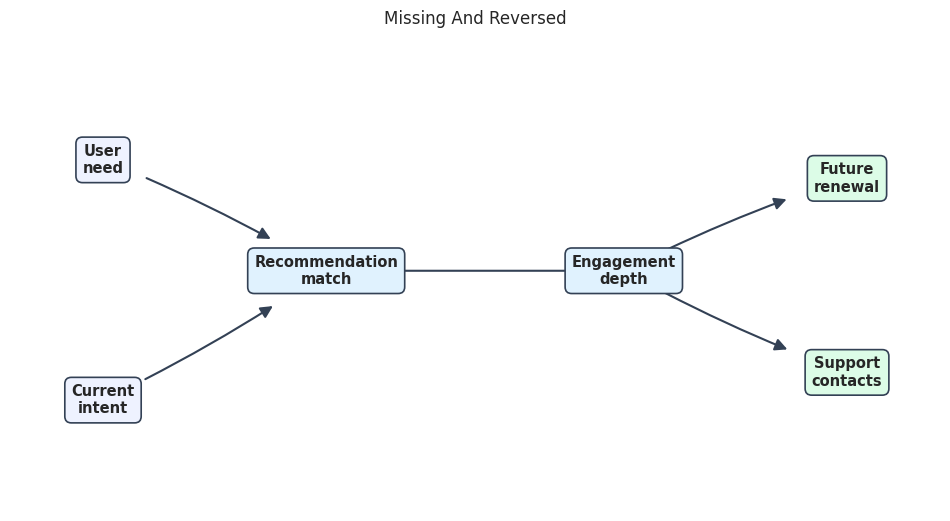

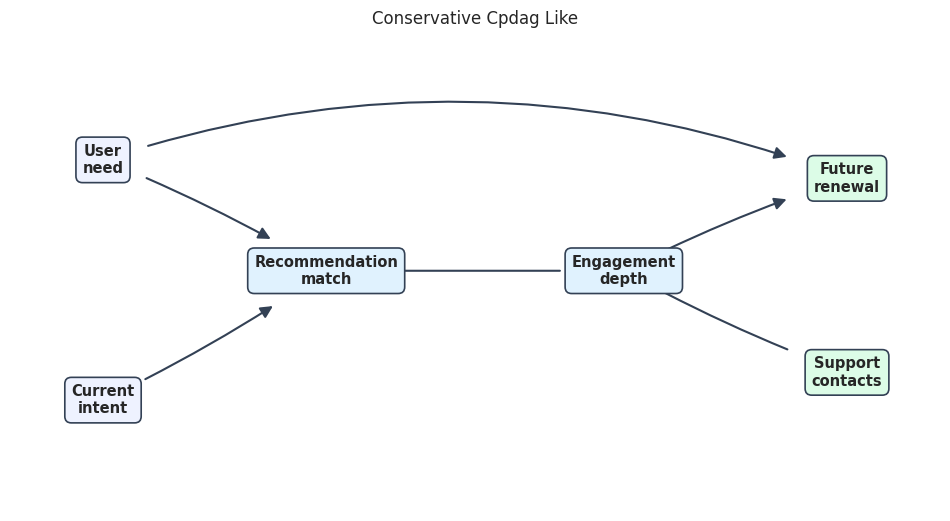

In [9]:
for candidate_name, candidate_table in candidate_tables.items():
    candidate_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_{candidate_name}.png"
    render_edge_table_graph(
        candidate_table,
        node_labels,
        teaching_positions,
        candidate_name.replace("_", " ").title(),
        candidate_path,
        node_colors=teaching_node_colors,
        edge_radii=teaching_edge_radii,
        edge_color="#334155",
    )


The fixed-layout views make the reporting tradeoff tangible. A conservative graph may look less decisive, but it can be more honest. A graph with extra arrows may look impressive, yet it can encode false causal claims. In causal discovery, being explicit about uncertainty is usually better than making the graph look complete.


### Cross-Checking with causal-learn Built-In Metrics

causal-learn includes graph-comparison utilities for common benchmark metrics. The next step compares the true DAG to the `missing_and_reversed` candidate. We keep this as a cross-check because built-in metric definitions can be compact and library-specific. For a report, it is useful to show both: the library score and a plain-language table that says what kind of mistake happened.


In [10]:
missing_reversed_graph, _ = build_causallearn_graph(node_order, missing_and_reversed, graph_class=GeneralGraph)
adj_confusion = AdjacencyConfusion(true_dag, missing_reversed_graph)
arrow_confusion = ArrowConfusion(true_dag, missing_reversed_graph)
shd_score = SHD(true_dag, missing_reversed_graph).get_shd()
causal_learn_metric_table = pd.DataFrame(
    [
        {"metric_family": "SHD", "metric": "structural_hamming_distance", "value": shd_score},
        {"metric_family": "Adjacency", "metric": "true_positive", "value": adj_confusion.get_adj_tp()},
        {"metric_family": "Adjacency", "metric": "false_positive", "value": adj_confusion.get_adj_fp()},
        {"metric_family": "Adjacency", "metric": "false_negative", "value": adj_confusion.get_adj_fn()},
        {"metric_family": "Adjacency", "metric": "precision", "value": adj_confusion.get_adj_precision()},
        {"metric_family": "Adjacency", "metric": "recall", "value": adj_confusion.get_adj_recall()},
        {"metric_family": "Arrow", "metric": "true_positive", "value": arrow_confusion.get_arrows_tp()},
        {"metric_family": "Arrow", "metric": "false_positive", "value": arrow_confusion.get_arrows_fp()},
        {"metric_family": "Arrow", "metric": "false_negative", "value": arrow_confusion.get_arrows_fn()},
        {"metric_family": "Arrow", "metric": "precision", "value": arrow_confusion.get_arrows_precision()},
        {"metric_family": "Arrow", "metric": "recall", "value": arrow_confusion.get_arrows_recall()},
    ]
)
causal_learn_metric_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_causal_learn_builtin_metrics.csv", index=False)
causal_learn_metric_table


,metric_family,metric,value
0,SHD,structural_hamming_distance,2.000000
1,Adjacency,true_positive,5.000000
2,Adjacency,false_positive,0.000000
3,Adjacency,false_negative,1.000000
4,Adjacency,precision,1.000000
5,Adjacency,recall,0.833333
6,Arrow,true_positive,4.000000
7,Arrow,false_positive,1.000000
8,Arrow,false_negative,2.000000
9,Arrow,precision,0.800000


The built-in metrics agree with the qualitative diagnosis: this candidate recovered most adjacencies but made direction mistakes. The important workflow lesson is to pair numeric metrics with an edge-level explanation. A single SHD value is useful for benchmarking, but it does not tell a stakeholder which causal claims changed.


#### Metric Selection Guide

This final guide summarizes which metric to emphasize for different discovery questions. The best metric depends on the decision the graph will support. If a graph will be used only to reduce a modeling feature set, adjacency recall may matter more than arrow precision. If a graph will support causal claims or intervention planning, arrow errors become much more consequential.


| question | metric_to_start_with | watch_out_for |
| --- | --- | --- |
| Did we find the right connected variable pairs? | Adjacency precision and adjacency recall | High adjacency recall can still hide many false directions. |
| Did we orient arrows correctly? | Arrow precision and arrow recall | A conservative CPDAG/PAG may leave valid uncertainty visible and avoid unsupported arrow claims. |
| How far is the whole graph from the reference graph? | SHD | SHD is compact but should be decomposed into missing, extra, and reversed edge errors. |
| Can we use this graph for causal decisions? | Edge-level audit plus domain review | Graph recovery metrics do not validate causal assumptions by themselves. |


This guide turns the lesson into a reusable checklist. Before reporting a discovered graph, decide whether the work needs adjacency recovery, direction recovery, equivalence-class reporting, or a decision-ready causal story. Different goals require different evidence.


## Summary


This section establishes the graph vocabulary needed for the rest of the causal-learn sequence. From here, the sequence starts generating synthetic data, using a clear distinction between the true graph, partially oriented algorithm output, and evaluation metrics that preserve uncertainty.
